# 01 · 数据:怎么选、怎么拼
**这本讲我们怎么挑数据、怎么把多源拼成一张表。** 不写代码也能看懂;想自己从原始数据集建缓存,
需要下载「上海城市数据集」(见 `数据集说明.md`)。没下也没关系——随包已带 3 站缓存,后面几本都能离线跑。

> 为什么单独讲数据?因为「权力 → 形态」的可信度,**全押在数据怎么选**。
> OSM 版(新加坡)tag 太稀疏,36% 的楼只能标 unknown;上海这套换成 5 个各司其职的本地来源,unknown 压到 1–6%。

## 怎么执行
- 点一格,按 **Shift+Enter** 执行;或选单 Run → Run All Cells 从头跑。
- 结果与图会显示在该格下面。代码都在 `engine/` 文件夹,平时不用打开。

In [2]:
# 让 notebook 找到 engine 里的代码(这格不用改,直接执行)
import sys, os
sys.path.insert(0, os.path.abspath("engine"))
# 清掉旧的引擎模块缓存:改了 config/engine 后,重跑本格即刻生效(免重启内核)
for _m in [k for k in list(sys.modules) if k in ("config", "common", "operators", "measure")
           or k == "plots" or k.startswith("plots.") or k == "prints" or k.startswith("prints.")]:
    del sys.modules[_m]
import config, common as C, plots, prints
# prints.ready()
plots.capture("01")   # 开启自动存图:本册每张图都会存到 out/<slug>/Step_01/<时间戳>/

'20260701_103648'

## 一、为什么要"多源"
一个来源讲不清权力。我们要回答三件事,各需不同数据:
1. **楼长什么样、多高?** —— 几何 + 实测高度。
2. **这块地是干嘛的(政府?商业?居住?)** —— 离散的用途主键。
3. **政府办公 vs 商务办公怎么分开?** —— 用途类别要**自带政商之分**(OSM 的 `office=*` 做不到)。

所以用**级联**:一个主键来源打底,覆盖不到的地方再用次级来源补。

## 二、5 个 spine 文件(每个为什么选它)
| 角色 | 文件 | 给什么 | 为什么选它 |
|---|---|---|---|
| **几何+高度** | `01-建筑轮廓/②AI解析/…-带高度` | footprint + **实测** Height(0–338m) | 终于有真超高层 token(陆家嘴 338m),不再靠楼层×3.5 估 |
| **离散主键** | `09-开源土地利用/…开源建设用地`(EULUC) | 地块级用途 class2 | 面状、覆盖 90%+;`行政办公`501 vs `商务办公`201 **类别里就分政商** |
| **补充用途** | `01-建筑轮廓/③其它/…-带年份`(Function) | 建筑级 Function/Age | EULUC 没覆盖到处补;Office 不分政商,故只作补充 |
| **辅助** | `02-POI&AOI/…/百度AOI` | type/结构/价格/时间 | 再补一层;价格/结构仅作离散 tag、不外发原值 |
| **范围** | `03-行政区/…/乡镇街道边界` | 街道多边形 | 研究单位 = 街道(非方形、变大小),不是任意方框 |

In [3]:
# 看 5 个 spine 文件的路径,以及你机器上是否有(没有=还没下数据集,用随包缓存即可)
prints.spine_paths()

AttributeError: module 'prints' has no attribute 'spine_paths'

## 三、多源怎么"拼"在一起(空间 join)
楼是**点/面**,用途是**地块面**。拼法:取每栋楼的代表点(质心),看它**落在**哪块用途面里
(`within`),把那块的用途贴回这栋楼。AOI 同理。这叫**空间连接 spatial join**。

然后**级联取第一个命中**:先问 EULUC,有就定;没有再问 Function;再没有问 AOI;都没有 = unknown。
一栋楼最终只拿到**一个**用途来源的判定——保持离散、可读、可争论。

## 四、亲手建缓存(需要数据集;没下就跳过这格)
把 `config.py` 的 `DATASET_ROOT` 指到你解压的「上海城市数据集」根目录,存档、回到第二格重跑,再跑这格:
它会对当前 `SLUG` 做**裁切 + 多源 join**,写出 `data/<slug>/buildings.parquet`。
没设 `DATASET_ROOT` 时,这格会自动**改用随包缓存**,不报错。

In [ ]:
# 有数据集 → 亲手建缓存;没有 → 用随包缓存。两条路都通(分支细节在 C.build_or_load 里)
df, source = C.build_or_load(config.SLUG)
prints.prepared(df, source)

  建缓存 陆家嘴街道(lujiazui):3263 栋 → data\lujiazui\buildings.parquet
拼好了:3263 栋  ·  陆家嘴街道


## 五、看一眼拼出来的表
每栋楼现在带着多源信息:`height_m`(实测高度)、`euluc`(地块用途)、`function`、`aoi_*`。
后面「怎么 mapping」那本,就靠这几列把每栋楼对应到一个权利方。

覆盖率:
  euluc     93%
  function  42%

样例(前 8 栋的多源列):
    height_m   euluc  function aoi_type2 aoi_type1
0  14.862233  商务办公用地       NaN        楼宇      商务住宅
1  14.217366     NaN       NaN       NaN       NaN
2  45.997633  商业服务用地       NaN        楼宇      商务住宅
3  63.896900  商务办公用地       NaN      宾馆酒店      住宿服务
4  90.024500  商务办公用地  Business      宾馆酒店      住宿服务
5  89.570900  商务办公用地  Business      宾馆酒店      住宿服务
6  21.803766  商务办公用地       NaN        楼宇      商务住宅
7  83.906233  商务办公用地    Office        楼宇      商务住宅
  -> saved out\lujiazui\Step_01\20260701_034433\01_data_overview.png


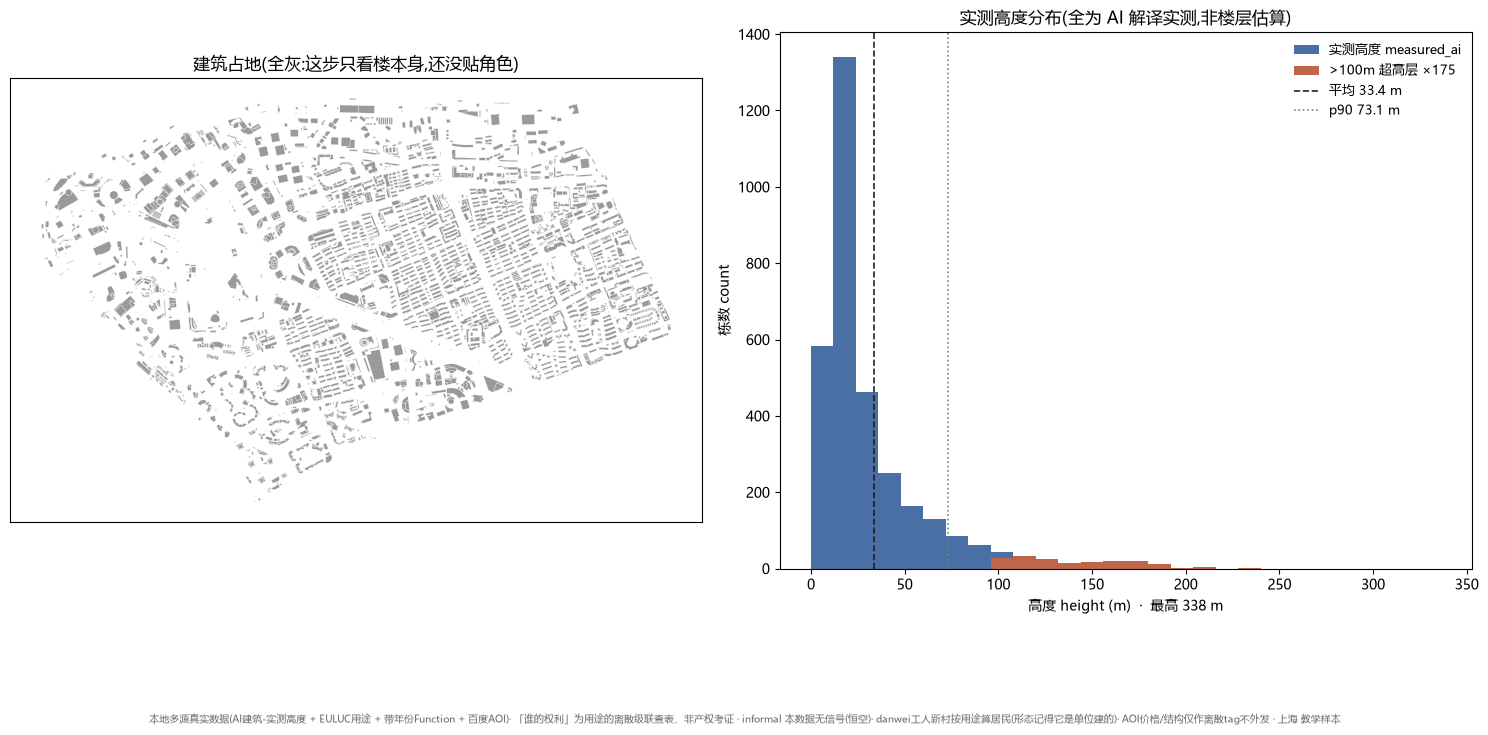

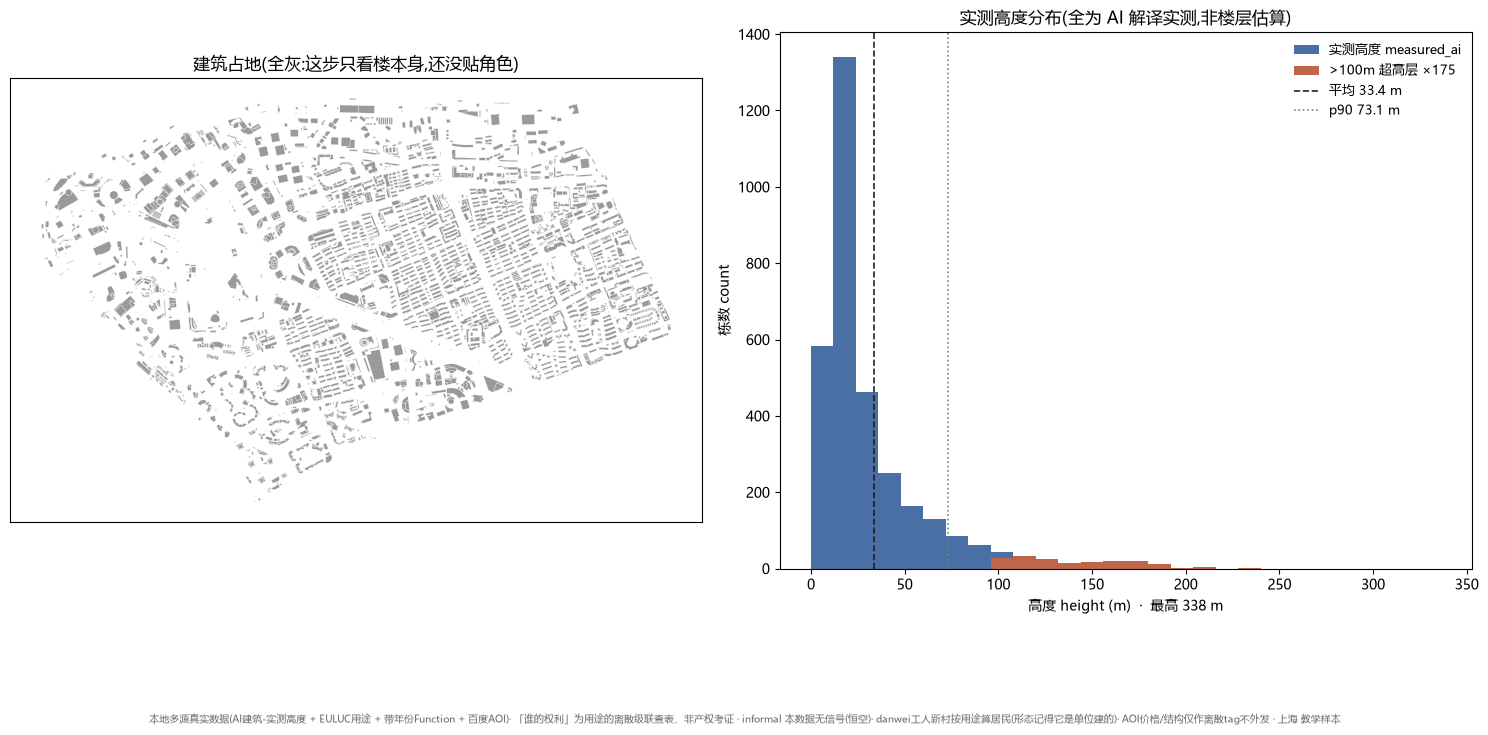

In [ ]:
# 看一眼拼出来的表:多源覆盖率 + 前 8 栋,再画一张 footprint + 实测高度分布
prints.coverage(df)
plots.data_overview(df)

## 诚实边界(数据这一关)
- **EULUC 是地块(面)级、优先于建筑级 Function**:居住地块里零星的小公建会被并入「居民」。
- **danwei 看不见**:工人新村是国家/单位建的,但用途=居住 → 会被算成居民;只有形态记得它是单位建的。
- **informal 本数据无信号 → 恒为空**,不从形态硬猜。
- AI 高度对极端超高层(>~340m)可能低估;AOI 价格/结构仅作离散 tag、不外发原值。

> 这些不是 bug,是**把简化讲清楚**。下一本:[`02 映射`] —— 这张多源表怎么变成「谁算谁的」。